##  1) Load the dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("old_chat.txt",header=None,error_bad_lines=False,encoding='utf8')

C:\Users\smani\AppData\Local\Temp\ipykernel_30880\2516945227.py:1: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  df = pd.read_csv("old_chat.txt",header=None,error_bad_lines=False,encoding='utf8')
Skipping line 833: expected 4 fields, saw 5
Skipping line 837: expected 4 fields, saw 5
Skipping line 846: expected 4 fields, saw 5
Skipping line 848: expected 4 fields, saw 5
Skipping line 862: expected 4 fields, saw 7
Skipping line 863: expected 4 fields, saw 5
Skipping line 1473: expected 4 fields, saw 6
Skipping line 2444: expected 4 fields, saw 8
Skipping line 2445: expected 4 fields, saw 7
Skipping line 2446: expected 4 fields, saw 7
Skipping line 2903: expected 4 fields, saw 5



In [3]:
df

,0,1,2,3
0,2/17/23,9:12 PM - Messages and calls are end-to-end e...,listen to,or share them. *Learn more*
1,4/15/23,8:59 PM - +91 99528 85972: Photo anupunga,NaN,NaN
2,4/15/23,9:13 PM - 🤗: Sari ga send pandra,NaN,NaN
3,4/15/23,9:15 PM - +91 99528 85972: Hmm,NaN,NaN
4,4/15/23,9:17 PM - 🤗: Loading la iruku,NaN,NaN
...,...,...,...,...
3370,6/20/23,9:04 AM - +91 99528 85972: Nee unnoda wrk ah ...,NaN,NaN
3371,Naa first sonnathu than eppavum enakku pudikkala,NaN,NaN,NaN
3372,Enakku pudikkala nu therunchathuku aprm nee ip...,NaN,NaN,NaN
3373,3/12/26,3:25 PM - Your security code with +91 99528 8...,NaN,NaN


## 2) Data processing 

In [4]:
#Check the null values
df.isnull().sum()

0       0
1     122
2    3326
3    3353
dtype: int64

In [5]:
#Rmove the null values
#df.dropna()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3375 entries, 0 to 3374
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       3375 non-null   object
 1   1       3253 non-null   object
 2   2       49 non-null     object
 3   3       22 non-null     object
dtypes: object(4)
memory usage: 105.6+ KB


In [7]:
#To delete the first row data which is no useful
df = df.drop(0)

In [8]:
df = df.drop(index=[3374,3373])

In [9]:
#Drop the no useful rows data
df = df.drop([2,3], axis=1)

#Give name to the columns
df.columns=["Date","Chat"]

In [10]:
df

,Date,Chat
1,4/15/23,8:59 PM - +91 99528 85972: Photo anupunga
2,4/15/23,9:13 PM - 🤗: Sari ga send pandra
3,4/15/23,9:15 PM - +91 99528 85972: Hmm
4,4/15/23,9:17 PM - 🤗: Loading la iruku
5,4/15/23,9:18 PM - +91 99528 85972: Ok da
...,...,...
3368,6/20/23,3:09 AM - 🤗: Sorry Athu la mistake aitu chu 😆
3369,Na send pana message Ella ne padi paya nu kuda...,NaN
3370,6/20/23,9:04 AM - +91 99528 85972: Nee unnoda wrk ah ...
3371,Naa first sonnathu than eppavum enakku pudikkala,NaN


In [11]:
#Split the time data chat
Message=df["Chat"].str.split("-",n=1,expand=True)

#add the split the into main dataset
df["Time"]=Message[0]

#Split the user name in the data
Message1=Message[1].str.split(":",n=1,expand=True)

#Add the split data into main dataset
df["Name"]=Message1[0]
df["Chat"]=Message1[1]

#Rearrange the cloumns
df=df[["Date","Time","Name","Chat"]]

In [12]:
#Message

In [13]:
#Message1

In [14]:
df

,Date,Time,Name,Chat
1,4/15/23,8:59 PM,+91 99528 85972,Photo anupunga
2,4/15/23,9:13 PM,🤗,Sari ga send pandra
3,4/15/23,9:15 PM,+91 99528 85972,Hmm
4,4/15/23,9:17 PM,🤗,Loading la iruku
5,4/15/23,9:18 PM,+91 99528 85972,Ok da
...,...,...,...,...
3368,6/20/23,3:09 AM,🤗,Sorry Athu la mistake aitu chu 😆
3369,Na send pana message Ella ne padi paya nu kuda...,NaN,NaN,NaN
3370,6/20/23,9:04 AM,+91 99528 85972,Nee unnoda wrk ah paru naa ennoda wrk pakkara
3371,Naa first sonnathu than eppavum enakku pudikkala,NaN,NaN,NaN


In [15]:
#Remove the null values
df.dropna()

,Date,Time,Name,Chat
1,4/15/23,8:59 PM,+91 99528 85972,Photo anupunga
2,4/15/23,9:13 PM,🤗,Sari ga send pandra
3,4/15/23,9:15 PM,+91 99528 85972,Hmm
4,4/15/23,9:17 PM,🤗,Loading la iruku
5,4/15/23,9:18 PM,+91 99528 85972,Ok da
...,...,...,...,...
3365,6/20/23,3:00 AM,🤗,Una kaga Yapa yum Na irupa Apa
3366,6/20/23,3:01 AM,🤗,Unaku pudi kala Na Kandi pa en kuda pasa tha
3367,6/20/23,3:01 AM,🤗,Ena block kuda pani tu 🥲
3368,6/20/23,3:09 AM,🤗,Sorry Athu la mistake aitu chu 😆


## 3) Sentimental Analysis 

In [16]:
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\smani\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [17]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [18]:
#In SentimentIntensityAnalyzer Data preprocessing text to number convert is no need, the model already have that futures 

In [19]:
dataset=df

In [20]:
dataset["Chat"].iloc[4]

' Ok da'

In [21]:
sid = SentimentIntensityAnalyzer()

In [22]:
#Polarity scores checks the sentiment of a piece of text
senti=sid.polarity_scores(dataset['Chat'][2])

In [23]:
senti

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [24]:
#The four values mean:

#neg → how negative the text is
#neu → how neutral the text is
#pos → how positive the text is
#compound → overall sentiment score

#If compound values 
#compound > 0    → Positive
#compound < 0    → Negative
#compound ≈ 0    → Neutral

In [25]:
#Give the Polarity score to all rows in the dataset and create new columns
def sentimentalAnalysis(data,columnname):
        
        #downloading vader_lexicon for the process
        import matplotlib.pyplot as plt
        import seaborn as sns
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data['compound']  = data['scores'].apply(lambda score_dict: score_dict['compound'])
        data['Negtive']  = data['scores'].apply(lambda score_dict: score_dict['neg'])
        data['Postive']  = data['scores'].apply(lambda score_dict: score_dict['pos'])
        data['Neutral']  = data['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data['comp_score'] = data['compound'].apply(lambda c: 'positive' if c >=0 else 'negative')
        plt.clf()
        
        comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data['comp_score'].value_counts())
        return posneg,data

C:\Users\smani\AppData\Local\Temp\ipykernel_30880\3533224605.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)
C:\Users\smani\AppData\Local\Temp\ipykernel_30880\3533224605.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
C:\Users\smani\AppData\Local\Temp\ipykernel_30880\3533224605.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

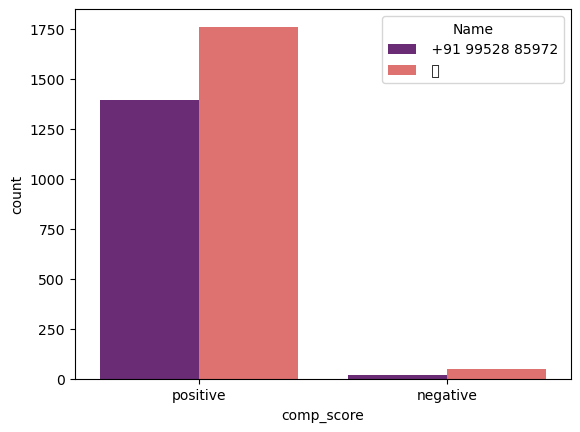

In [26]:
pos,data_senti = sentimentalAnalysis(dataset, columnname="Chat")

In [27]:
data_senti

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score
1,4/15/23,8:59 PM,+91 99528 85972,Photo anupunga,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive
2,4/15/23,9:13 PM,🤗,Sari ga send pandra,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive
3,4/15/23,9:15 PM,+91 99528 85972,Hmm,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive
4,4/15/23,9:17 PM,🤗,Loading la iruku,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive
5,4/15/23,9:18 PM,+91 99528 85972,Ok da,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,positive
...,...,...,...,...,...,...,...,...,...,...
3365,6/20/23,3:00 AM,🤗,Una kaga Yapa yum Na irupa Apa,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive
3366,6/20/23,3:01 AM,🤗,Unaku pudi kala Na Kandi pa en kuda pasa tha,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive
3367,6/20/23,3:01 AM,🤗,Ena block kuda pani tu 🥲,"{'neg': 0.42, 'neu': 0.58, 'pos': 0.0, 'compou...",-0.4404,0.420,0.000,0.580,negative
3368,6/20/23,3:09 AM,🤗,Sorry Athu la mistake aitu chu 😆,"{'neg': 0.481, 'neu': 0.519, 'pos': 0.0, 'comp...",-0.4019,0.481,0.000,0.519,negative


In [28]:
neg = data_senti[data_senti["comp_score"]=="negative"]

In [29]:
pos

,comp_score
positive,3153
negative,66


## Sentimental Analysis Completed

## Topic modeling 

In [30]:
#Topic modeling technique used to automatically discover the main topics/themes present in a collection of text.

In [31]:
#preprocess the dataset using TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [33]:
#Fit - Learns from the data (Learn)
#Fit_trandform - Converts data using what was already learned (apply)
#transform - Learns and converts (learn + apply)

In [34]:
#Topic modeling algorithm
from sklearn.decomposition import NMF
#n_components it 5 topics collections
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)

NMF(n_components=5, random_state=42)

In [35]:
for index,topic in enumerate(nmf_model.components_):
    results=([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)

['na', 'ga', 'va', 'ohhh', 'ohh', 'paru', 'sapudu', 'ma', 'da', 'ok']
['achu', '15', 'poi', 'nee', 'ama', 'da', 'illa', 'oii', 'media', 'omitted']
['ohh', 'neenga', 'saptan', 'illa', 'sari', 'ohhh', 'ama', 'da', 'seri', 'hmm']
['sari', 'neenga', 'saptan', 'ne', 'ohhh', 'nee', 'da', 'ama', 'seri', 'mm']
['tha', 'cha', 'pandra', 'ga', 'la', 'ne', 'ena', 'ma', 'ya', 'sapta']


In [36]:
#Store the Topic modeling result into the data table
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)

C:\Users\smani\AppData\Local\Temp\ipykernel_30880\4185603120.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Topic"]=topic_results.argmax(axis=1)


In [37]:
df

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
1,4/15/23,8:59 PM,+91 99528 85972,Photo anupunga,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive,4
2,4/15/23,9:13 PM,🤗,Sari ga send pandra,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive,4
3,4/15/23,9:15 PM,+91 99528 85972,Hmm,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive,2
4,4/15/23,9:17 PM,🤗,Loading la iruku,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive,4
5,4/15/23,9:18 PM,+91 99528 85972,Ok da,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,positive,0
...,...,...,...,...,...,...,...,...,...,...,...
3365,6/20/23,3:00 AM,🤗,Una kaga Yapa yum Na irupa Apa,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive,4
3366,6/20/23,3:01 AM,🤗,Unaku pudi kala Na Kandi pa en kuda pasa tha,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,positive,4
3367,6/20/23,3:01 AM,🤗,Ena block kuda pani tu 🥲,"{'neg': 0.42, 'neu': 0.58, 'pos': 0.0, 'compou...",-0.4404,0.420,0.000,0.580,negative,4
3368,6/20/23,3:09 AM,🤗,Sorry Athu la mistake aitu chu 😆,"{'neg': 0.481, 'neu': 0.519, 'pos': 0.0, 'comp...",-0.4019,0.481,0.000,0.519,negative,4


In [40]:
df["Topic"].value_counts()

4    2126
0     493
2     337
3     138
1     125
Name: Topic, dtype: int64

In [38]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\smani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

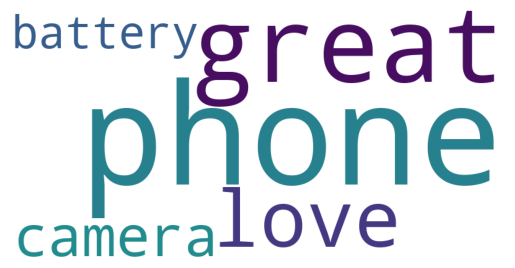

In [41]:
#Example code for WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = "I love this phone. The phone has a great camera and great battery."

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()